In [24]:
from langchain_groq import ChatGroq
from langgraph.graph import START,END,StateGraph
from dotenv import load_dotenv

In [25]:
load_dotenv()

True

In [26]:
llm = ChatGroq(model='openai/gpt-oss-120b')

In [27]:
from pydantic import BaseModel

class llm_State(BaseModel):
    question: str = ''
    answer: str = ''

In [28]:
def generate_ans(state: llm_State)-> dict:

    question  = state.question

    prompt = f'Answer the follwing question{question}'

    answer = llm.invoke(prompt).content

    state.answer = answer

    return state


In [29]:
graph = StateGraph(llm_State)

graph.add_node('generate_ans',generate_ans)

graph.add_edge(START,'generate_ans')
graph.add_edge('generate_ans',END)

workflow = graph.compile()

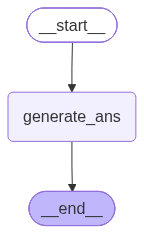

In [38]:
workflow

In [30]:
initial_state = {"question": "what is the wine city"}

final_state = workflow.invoke(initial_state)

In [37]:
 
print(final_state['question'],'\n')
final_state['answer']

what is the wine city 



'**Bordeaux, France** is the city most famously nicknamed **“the Wine City.”**  \n\n- **Why Bordeaux gets that title**\n  - It sits at the heart of one of the world’s largest and most prestigious wine‑growing regions.  \n  - The city’s history is inseparable from wine: merchants have been exporting Bordeaux wines for more than 800\u202fyears, and the famous “Bordeaux wine trade” helped shape modern commerce and finance.  \n  - Its historic “Port of the Moon” waterfront is lined with grand wine‑merchant warehouses, many of which are now museums, hotels, and restaurants that celebrate the region’s viticultural heritage.  \n  - The term “Bordeaux wine” is a global brand in itself, synonymous with quality red and white blends.\n\n- **Other cities that also wear the “Wine City” moniker**\n  - **Napa, California (USA)** – the hub of the Napa Valley wine region.  \n  - **Mendoza, Argentina** – the heart of Argentine Malbec production.  \n  - **Stellenbosch, South Africa** – a historic wine‑pr